# Loss Balancing

This notebook summarizes the loss-balancing experiment for thesis-ready reporting. The experiment compares data-only, static, warmup-static, and adaptive loss-weighting strategies for PINN training.

Pipeline script: `src/experiments/pipeline/run_weighting_comparison.py`  
Experiment catalogue: `src/experiments/README.md`  
Raw outputs: `outputs/weighting_comparison/`  
Table exports: `results/tables/03_loss_balancing/`

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def _find_repo_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {start}")

REPO = _find_repo_root()

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd
from IPython.display import display

from src.visualization.results_helpers import (
    aggregate_mean_sem,
    epoch_metrics_path,
    ensure_repo_root_on_path,
    eval_metric,
    load_posthoc_external_eval,
    load_json,
    mean_sem_text,
    overlay_posthoc_external_eval,
    read_epoch_metrics,
    seed_list,
    split_metric,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    log_minor_grid,
    method_color,
    save_figure,
    set_thesis_style,
)

REPO = ensure_repo_root_on_path(REPO)
ROOT = REPO / "outputs" / "weighting_comparison"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("loss_balancing")

set_thesis_style()

STRATEGY_ORDER = [
    "data_only",
    "static_tuned",
    "static_uniform",
    "data_warmup_static",
    "ma",
    "id",
    "dn",
    "ntk",
    "relobralo",
]
PRIMARY_STRATEGIES = [s for s in STRATEGY_ORDER if s != "relobralo"]
AUXILIARY_STRATEGIES = {"relobralo"}
ADAPTIVE_STRATEGIES = ["ma", "id", "dn", "ntk", "relobralo"]
COMPONENTS = ["data", "dt", "physics", "ic"]

STRATEGY_LABEL = {
    "data_only": "Data only",
    "static_tuned": "Static tuned",
    "static_uniform": "Static uniform",
    "data_warmup_static": "Warmup + static",
    "ma": "MA",
    "id": "ID",
    "dn": "DN",
    "ntk": "NTK",
    "relobralo": "ReLoBRaLo",
}
GROUP = {
    "data_only": "baseline",
    "static_tuned": "static",
    "static_uniform": "static",
    "data_warmup_static": "static",
    "ma": "adaptive",
    "id": "adaptive",
    "dn": "adaptive",
    "ntk": "adaptive",
    "relobralo": "adaptive",
}
STRATEGY_COLORS = {strategy: method_color(strategy) for strategy in STRATEGY_ORDER}
EXPECTED_SEEDS = ["s01", "s02", "s03"]

def strategy_label(strategy: str) -> str:
    return STRATEGY_LABEL.get(strategy, strategy)

def ordered(frame: pd.DataFrame, column: str = "strategy", order=STRATEGY_ORDER) -> pd.DataFrame:
    out = frame.copy()
    out[column] = pd.Categorical(out[column], categories=list(order), ordered=True)
    return out.sort_values(column).reset_index(drop=True)

def export_fig(fig, name: str):
    # Figure export disabled for repository submission; keep plot inline.
    paths = []
    plt.show()
    return paths

def sci_axis(ax, axis="y"):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    else:
        ax.xaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

## Data Loading

Run summaries are loaded from every weighting-comparison batch. Metrics are recovered from per-run `metrics.json` files where the summary CSV is incomplete, and duplicate `(strategy, seed)` entries are resolved by preferring completed runs with external ID/OOD evaluations.

In [2]:
summary_frames = []
for summary_path in sorted(ROOT.glob("*/summary.csv")):
    frame = pd.read_csv(summary_path)
    frame["batch"] = summary_path.parent.name
    summary_frames.append(frame)

if not summary_frames:
    raise FileNotFoundError(f"No summary.csv files found under {ROOT}")

runs_all = pd.concat(summary_frames, ignore_index=True, sort=False)

# Add manifest-only runs when a completed run exists on disk but is missing from a batch summary.
manifest_records = []
known = set(zip(runs_all["batch"].astype(str), runs_all["run_name"].astype(str)))
for batch_dir in sorted(ROOT.iterdir()):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    for record in manifest.get("runs", []):
        key = (batch_dir.name, str(record.get("run_name")))
        if key in known:
            continue
        row = {k: record.get(k) for k in [
            "run_name", "strategy", "scheme", "seed_label", "seed_value",
            "dataset_reference_id", "dataset_root", "id_eval_id", "id_eval_root",
            "ood_eval_id", "ood_eval_root", "status", "return_code", "failure_reason"
        ]}
        row["batch"] = batch_dir.name
        manifest_records.append(row)

if manifest_records:
    runs_all = pd.concat([runs_all, pd.DataFrame(manifest_records)], ignore_index=True, sort=False)

for col in ["strategy", "seed_label", "run_name", "status", "batch"]:
    runs_all[col] = runs_all[col].astype(str)

# Recover authoritative final/best metrics from metrics.json whenever available.
for idx, row in runs_all.iterrows():
    metrics = load_json(epoch_metrics_path(ROOT, row.batch, row.run_name).with_name("metrics.json"), default=None)
    if metrics is None:
        continue
    for section, prefix in [("best", "best"), ("final", "final")]:
        for eval_name, label in [("id_eval", "id_eval"), ("ood_eval", "ood_eval")]:
            for metric in ["mse", "rmse", "mae"]:
                column = f"{prefix}_{label}_{metric}"
                value = eval_metric(metrics, section, eval_name, metric)
                if not pd.isna(value):
                    runs_all.loc[idx, column] = value
        for split in ["train", "val", "test"]:
            for metric in ["mse", "rmse", "mae"]:
                column = f"{prefix}_{split}_{metric}" if prefix == "best" else f"final_{split}_{metric}"
                value = split_metric(metrics, section, split, metric)
                if not pd.isna(value):
                    runs_all.loc[idx, column] = value

numeric_cols = [col for col in runs_all.columns if col not in {"run_name", "strategy", "scheme", "seed_label", "dataset_reference_id", "dataset_root", "id_eval_id", "id_eval_root", "ood_eval_id", "ood_eval_root", "run_dir", "status", "failure_reason", "log_file", "epoch_metrics_path", "best_checkpoint_path", "batch"}]
for col in numeric_cols:
    runs_all[col] = pd.to_numeric(runs_all[col], errors="coerce")

posthoc_eval = load_posthoc_external_eval(ROOT)
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")
runs_all = overlay_posthoc_external_eval(runs_all, posthoc_eval, on=("batch", "run_name"))
runs_all["has_posthoc_eval"] = runs_all.get("posthoc_status", pd.Series(index=runs_all.index, dtype=object)).eq("completed")
runs_all["external_eval_source"] = np.where(runs_all["has_posthoc_eval"], "posthoc_checkpoint", "training_run_metrics")

runs_all["has_id_eval"] = pd.to_numeric(runs_all["best_id_eval_mse"], errors="coerce").notna()
runs_all["has_ood_eval"] = pd.to_numeric(runs_all["best_ood_eval_mse"], errors="coerce").notna()
runs_all["has_complete_eval"] = runs_all["has_id_eval"] & runs_all["has_ood_eval"]
runs_all["is_auxiliary"] = runs_all["strategy"].isin(AUXILIARY_STRATEGIES)
runs_all["is_primary"] = (
    runs_all["strategy"].isin(PRIMARY_STRATEGIES)
    & runs_all["status"].astype(str).eq("completed")
    & runs_all["has_posthoc_eval"]
    & runs_all["has_complete_eval"]
)
runs_all["group"] = runs_all["strategy"].map(GROUP).fillna("other")
runs_all["batch_sort"] = pd.to_numeric(runs_all["batch"], errors="coerce")
runs_all["completion_rank"] = (
    runs_all["has_posthoc_eval"].astype(int) * 100
    + runs_all["has_complete_eval"].astype(int) * 10
    + runs_all["status"].astype(str).eq("completed").astype(int)
)

runs = (
    runs_all.sort_values(["strategy", "seed_label", "completion_rank", "batch_sort"], ascending=[True, True, False, False])
    .drop_duplicates(["strategy", "seed_label"], keep="first")
    .drop(columns=["completion_rank", "batch_sort"])
    .reset_index(drop=True)
)
runs = ordered(runs)
primary = runs[runs["is_primary"]].copy()
auxiliary = runs[runs["is_auxiliary"]].copy()
ood_available = runs[runs["has_ood_eval"]].copy()

# Scratch export disabled for repository submission; keep derived data in memory.

print(f"Loaded {len(runs_all)} raw rows and retained {len(runs)} strategy-seed runs after duplicate resolution.")
print(f"Primary runs: {len(primary)} | auxiliary runs: {len(auxiliary)}")

Loaded 36 raw rows and retained 27 strategy-seed runs after duplicate resolution.
Primary runs: 24 | auxiliary runs: 3


/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_18420/828573812.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs_all["completion_rank"] = (


## Completeness

In [3]:
completion_rows = []
for strategy in STRATEGY_ORDER:
    subset = runs[runs["strategy"] == strategy]
    present = sorted(subset["seed_label"].dropna().astype(str).unique())
    complete = sorted(subset.loc[subset["has_complete_eval"], "seed_label"].dropna().astype(str).unique())
    missing = [seed for seed in EXPECTED_SEEDS if seed not in present]
    completion_rows.append({
        "Strategy": strategy_label(strategy),
        "Group": GROUP.get(strategy, "other"),
        "Seeds present": ", ".join(present) if present else "n/a",
        "Complete ID/OOD seeds": ", ".join(complete) if complete else "n/a",
        "Missing expected seeds": ", ".join(missing) if missing else "none",
        "n": len(subset),
    })
completion = pd.DataFrame(completion_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
display(completion)

,Strategy,Group,Seeds present,Complete ID/OOD seeds,Missing expected seeds,n
0,Data only,baseline,"s01, s02, s03","s01, s02, s03",none,3
1,Static tuned,static,"s01, s02, s03","s01, s02, s03",none,3
2,Static uniform,static,"s01, s02, s03","s01, s02, s03",none,3
3,Warmup + static,static,"s01, s02, s03","s01, s02, s03",none,3
4,MA,adaptive,"s01, s02, s03","s01, s02, s03",none,3
5,ID,adaptive,"s01, s02, s03","s01, s02, s03",none,3
6,DN,adaptive,"s01, s02, s03","s01, s02, s03",none,3
7,NTK,adaptive,"s01, s02, s03","s01, s02, s03",none,3
8,ReLoBRaLo,adaptive,"s01, s02, s03","s02, s03",none,3


## Accuracy And Runtime Summary

The main comparison uses the primary strategies only. ReLoBRaLo is kept as an auxiliary result because it was treated separately in the original analysis.

In [4]:
POSTHOC_SUMMARY_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90",
    "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_id_eval_trajectory_rmse_mean", "best_id_eval_trajectory_rmse_p90",
    "best_id_eval_trajectory_rmse_p95", "best_id_eval_trajectory_rmse_max",
    "best_id_eval_trajectory_max_abs_error_mean",
    "best_id_eval_trajectory_max_abs_error_p95",
    "best_id_eval_trajectory_max_abs_error_max",
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90",
    "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_rmse_mean", "best_ood_eval_trajectory_rmse_p90",
    "best_ood_eval_trajectory_rmse_p95", "best_ood_eval_trajectory_rmse_max",
    "best_ood_eval_trajectory_max_abs_error_mean",
    "best_ood_eval_trajectory_max_abs_error_p95",
    "best_ood_eval_trajectory_max_abs_error_max",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
]
SUMMARY_METRICS = POSTHOC_SUMMARY_METRICS + ["final_test_mse", "training_seconds", "total_seconds"]
POSTHOC_METRIC_LABELS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_rmse", "ID RMSE"),
    ("best_id_eval_mae", "ID MAE"),
    ("best_id_eval_max_abs_error", "ID max abs error"),
    ("best_id_eval_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("best_id_eval_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("best_id_eval_trajectory_mse_max", "ID trajectory MSE max"),
    ("best_id_eval_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("best_id_eval_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("best_id_eval_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("best_id_eval_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("best_id_eval_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("best_id_eval_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("best_id_eval_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("best_id_eval_n_rows", "ID rows"),
    ("best_id_eval_n_trajectories", "ID trajectories"),
    ("best_ood_eval_mse", "OOD MSE"),
    ("best_ood_eval_rmse", "OOD RMSE"),
    ("best_ood_eval_mae", "OOD MAE"),
    ("best_ood_eval_max_abs_error", "OOD max abs error"),
    ("best_ood_eval_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("best_ood_eval_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("best_ood_eval_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("best_ood_eval_trajectory_mse_max", "OOD trajectory MSE max"),
    ("best_ood_eval_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("best_ood_eval_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("best_ood_eval_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("best_ood_eval_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("best_ood_eval_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("best_ood_eval_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("best_ood_eval_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("best_ood_eval_n_rows_before_filter", "OOD rows before filter"),
    ("best_ood_eval_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("best_ood_eval_n_rows", "OOD rows"),
    ("best_ood_eval_n_trajectories", "OOD trajectories"),
]
POSTHOC_COUNT_METRICS = {
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
}

primary_agg = aggregate_mean_sem(
    primary,
    group_cols="strategy",
    metrics=SUMMARY_METRICS,
    order_col="strategy",
    order=PRIMARY_STRATEGIES,
)
aux_agg = aggregate_mean_sem(
    auxiliary,
    group_cols="strategy",
    metrics=SUMMARY_METRICS,
    order_col="strategy",
    order=STRATEGY_ORDER,
)

def metric_text(row: pd.Series, metric: str, *, decimals: int = 2, scientific: bool = True) -> str:
    if pd.isna(row.get(f"{metric}_mean")) and pd.isna(row.get(f"{metric}_sem")):
        return "n/a"
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)


def formatted_summary(agg: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in agg.iterrows():
        record = {
            "Strategy": strategy_label(row["strategy"]),
            "Seeds": row.get("seeds", ""),
        }
        for metric, label in POSTHOC_METRIC_LABELS:
            if metric in POSTHOC_COUNT_METRICS:
                record[label] = metric_text(row, metric, decimals=0, scientific=False)
            else:
                record[label] = metric_text(row, metric, decimals=2)
        record["Test MSE"] = metric_text(row, "final_test_mse", decimals=2)
        record["Training time [h]"] = mean_sem_text(
            pd.Series({
                "training_seconds_mean": row.get("training_seconds_mean", np.nan) / 3600,
                "training_seconds_sem": row.get("training_seconds_sem", np.nan) / 3600,
            }),
            "training_seconds",
            decimals=2,
            scientific=False,
        )
        rows.append(record)
    return pd.DataFrame(rows)

summary_table_primary = formatted_summary(primary_agg)
summary_table_auxiliary = formatted_summary(aux_agg)
write_numeric_table(primary_agg, "loss_balancing")
write_table(summary_table_primary, "loss_balancing")
# Scratch export disabled for repository submission; keep derived data in memory.

display(summary_table_primary)
if not summary_table_auxiliary.empty:
    display(summary_table_auxiliary)

,Strategy,Seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,ID trajectory MSE max,...,OOD trajectory RMSE max,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,Test MSE,Training time [h]
0,Data only,"s01,s02,s03",3.58e-06 +/- 4.03e-07,1.89e-03 +/- 1.04e-04,1.20e-03 +/- 6.02e-05,4.82e-02 +/- 3.77e-04,3.58e-06 +/- 4.03e-07,6.98e-06 +/- 4.64e-07,9.52e-06 +/- 7.49e-07,3.13e-05 +/- 4.29e-07,...,7.28e-01 +/- 1.02e-02,2.03e-01 +/- 5.03e-03,8.45e-01 +/- 1.02e-02,1.17e+00 +/- 6.78e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,6.44e-06 +/- 2.35e-06,4.23 +/- 0.22
1,Static tuned,"s01,s02,s03",3.11e-06 +/- 7.86e-08,1.76e-03 +/- 2.24e-05,1.06e-03 +/- 2.79e-05,3.78e-02 +/- 1.69e-03,3.11e-06 +/- 7.86e-08,6.52e-06 +/- 2.79e-07,9.80e-06 +/- 6.11e-07,2.74e-05 +/- 2.02e-06,...,7.20e-01 +/- 1.36e-02,1.91e-01 +/- 2.23e-03,8.49e-01 +/- 1.33e-02,1.29e+00 +/- 8.62e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,6.02e-06 +/- 1.35e-06,4.12 +/- 0.13
2,Static uniform,"s01,s02,s03",1.60e-04 +/- 1.77e-05,1.26e-02 +/- 7.25e-04,8.55e-03 +/- 4.17e-04,7.23e-02 +/- 4.67e-03,1.60e-04 +/- 1.77e-05,3.94e-04 +/- 3.95e-05,5.75e-04 +/- 5.06e-05,1.11e-03 +/- 1.28e-04,...,6.86e-01 +/- 1.41e-02,1.51e-01 +/- 6.94e-03,5.76e-01 +/- 2.61e-02,1.20e+00 +/- 2.57e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,2.67e-04 +/- 5.02e-05,3.93 +/- 0.07
3,Warmup + static,"s01,s02,s03",3.03e-06 +/- 5.06e-07,1.73e-03 +/- 1.41e-04,1.05e-03 +/- 4.33e-05,2.93e-02 +/- 1.97e-03,3.03e-06 +/- 5.06e-07,5.48e-06 +/- 5.87e-07,8.87e-06 +/- 2.05e-06,3.93e-05 +/- 1.99e-05,...,7.01e-01 +/- 1.72e-02,1.92e-01 +/- 5.79e-03,8.50e-01 +/- 1.69e-02,1.35e+00 +/- 7.87e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,1.10e-05 +/- 3.23e-06,3.93 +/- 0.07
4,MA,"s01,s02,s03",9.00e-06 +/- 2.06e-06,2.96e-03 +/- 3.56e-04,2.06e-03 +/- 1.94e-04,2.14e-02 +/- 1.86e-03,9.00e-06 +/- 2.06e-06,2.04e-05 +/- 5.39e-06,2.61e-05 +/- 5.90e-06,6.88e-05 +/- 6.45e-06,...,6.92e-01 +/- 3.86e-02,1.43e-01 +/- 1.75e-02,6.20e-01 +/- 6.22e-02,1.17e+00 +/- 6.02e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,5.07e-05 +/- 1.54e-05,4.20 +/- 0.29
5,ID,"s01,s02,s03",7.77e-06 +/- 2.36e-06,2.73e-03 +/- 4.10e-04,1.90e-03 +/- 2.92e-04,2.00e-02 +/- 3.92e-03,7.77e-06 +/- 2.36e-06,1.58e-05 +/- 4.65e-06,2.08e-05 +/- 5.62e-06,6.10e-05 +/- 1.95e-05,...,6.50e-01 +/- 2.52e-02,1.48e-01 +/- 7.01e-03,6.75e-01 +/- 8.64e-03,1.17e+00 +/- 9.47e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,1.33e-05 +/- 2.61e-06,4.34 +/- 0.30
6,DN,"s01,s02,s03",1.00e-05 +/- 2.69e-06,3.10e-03 +/- 4.69e-04,2.22e-03 +/- 3.49e-04,2.57e-02 +/- 5.63e-03,1.00e-05 +/- 2.69e-06,2.04e-05 +/- 5.30e-06,2.90e-05 +/- 7.68e-06,8.09e-05 +/- 2.57e-05,...,6.43e-01 +/- 2.17e-02,1.31e-01 +/- 6.53e-03,5.68e-01 +/- 2.38e-02,1.17e+00 +/- 5.92e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,1.40e-05 +/- 3.53e-06,4.39 +/- 0.30
7,NTK,"s01,s02,s03",4.61e-06 +/- 2.99e-07,2.14e-03 +/- 7.07e-05,1.49e-03 +/- 2.87e-05,1.97e-02 +/- 3.31e-03,4.61e-06 +/- 2.99e-07,9.67e-06 +/- 1.34e-06,1.28e-05 +/- 2.45e-06,3.58e-05 +/- 5.18e-06,...,7.13e-01 +/- 2.88e-02,1.68e-01 +/- 8.40e-03,7.58e-01 +/- 2.04e-02,1.22e+00 +/- 8.67e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,6.23e-05 +/- 3.96e-05,4.50 +/- 0.29


,Strategy,Seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,ID trajectory MSE max,...,OOD trajectory RMSE max,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,Test MSE,Training time [h]
0,ReLoBRaLo,"s01,s02,s03",3.63e-04 +/- 7.05e-05,1.90e-02 +/- 1.86e-03,1.32e-02 +/- 1.78e-03,n/a,n/a,n/a,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,n/a,4.50e-03 +/- 2.97e-03,6.24 +/- 2.00


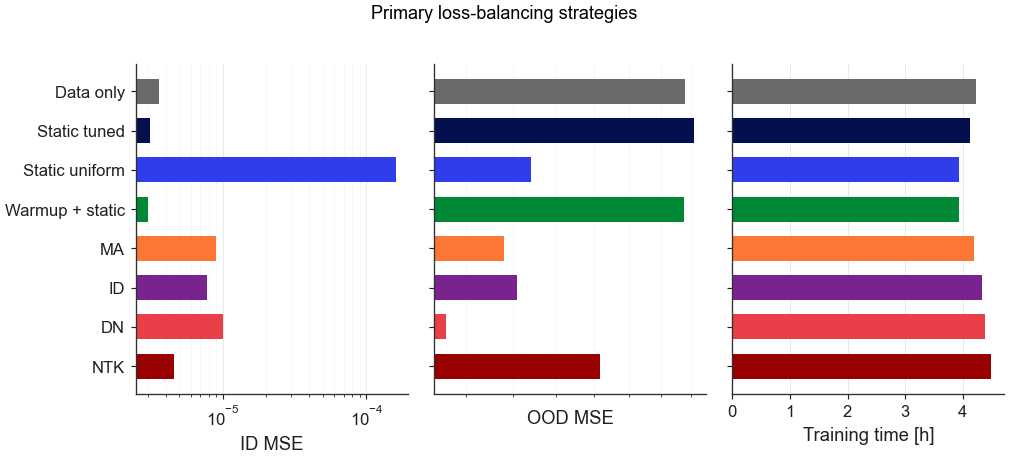

[]

In [5]:
plot_frame = primary_agg.copy()
plot_frame["label"] = plot_frame["strategy"].map(strategy_label)
plot_frame["training_hours_mean"] = plot_frame["training_seconds_mean"] / 3600

fig, axes = plt.subplots(1, 3, figsize=(8.6, 3.8), sharey=True)
y = np.arange(len(plot_frame))
bar_colors = [STRATEGY_COLORS[s] for s in plot_frame["strategy"]]

panels = [
    ("best_id_eval_mse_mean", "ID MSE", True),
    ("best_ood_eval_mse_mean", "OOD MSE", True),
    ("training_hours_mean", "Training time [h]", False),
]
for ax, (metric, xlabel, log_scale) in zip(axes, panels):
    ax.barh(y, plot_frame[metric], color=bar_colors, height=0.64)
    ax.set_xlabel(xlabel)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_frame["label"])
    if log_scale:
        ax.set_xscale("log")
        log_minor_grid(ax, axis="x")
    ax.grid(True, axis="x")
    ax.grid(False, axis="y")
    apply_thesis_axis_style(ax)

axes[0].invert_yaxis()
fig.suptitle("Primary loss-balancing strategies", y=1.02)
fig.tight_layout(w_pad=1.4)
export_fig(fig, "loss_balancing_primary_summary")

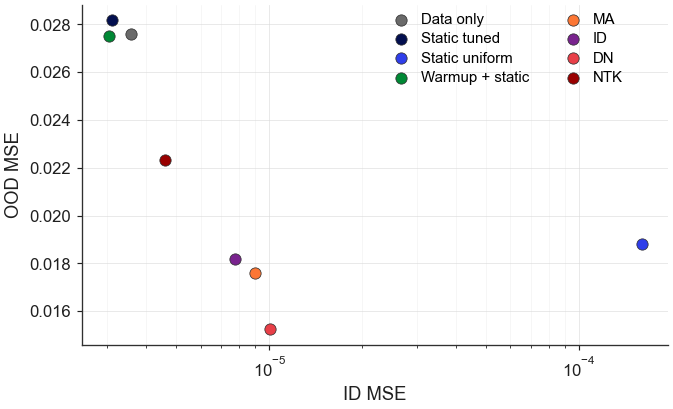

[]

In [6]:
fig, ax = plt.subplots(figsize=(5.8, 3.6))
for _, row in primary_agg.iterrows():
    strategy = row["strategy"]
    ax.scatter(
        row["best_id_eval_mse_mean"],
        row["best_ood_eval_mse_mean"],
        s=46,
        color=STRATEGY_COLORS[strategy],
        edgecolor=NEUTRAL_COLORS["axis"],
        linewidth=0.45,
        label=strategy_label(strategy),
        zorder=3,
    )

ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("ID MSE")
ax.set_ylabel("OOD MSE")
ax.legend(loc="center left", bbox_to_anchor=(0.5, 0.87), ncol=2)
log_minor_grid(ax, axis="both")
apply_thesis_axis_style(ax)
fig.tight_layout()
export_fig(fig, "loss_balancing_id_ood_tradeoff")

## Validation Components

These diagnostics show whether a strategy improves the supervised objective while letting residual terms drift, or whether it balances the raw and weighted validation objective components.

In [7]:
def final_validation_record(row):
    path = epoch_metrics_path(ROOT, row.batch, row.run_name)
    columns = ["global_epoch"] + [f"val_{c}_loss" for c in COMPONENTS] + [f"train_weight_{c}" for c in COMPONENTS]
    frame = read_epoch_metrics(path, columns=columns)
    if frame.empty:
        return None
    frame = frame.dropna(subset=[col for col in [f"val_{c}_loss" for c in COMPONENTS] if col in frame.columns], how="all")
    if frame.empty:
        return None
    final = frame.sort_values("global_epoch").iloc[-1]
    record = {"strategy": row.strategy, "seed_label": row.seed_label, "run_name": row.run_name}
    for component in COMPONENTS:
        val = final.get(f"val_{component}_loss", np.nan)
        weight = final.get(f"train_weight_{component}", np.nan)
        record[f"val_{component}_loss"] = val
        record[f"train_weight_{component}"] = weight
        record[f"weighted_val_{component}_loss"] = val * weight if pd.notna(val) and pd.notna(weight) else np.nan
    return record

component_records = [final_validation_record(row) for _, row in primary.iterrows()]
component_records = [record for record in component_records if record is not None]
component_run = ordered(pd.DataFrame(component_records), order=PRIMARY_STRATEGIES)
# Scratch export disabled for repository submission; keep derived data in memory.

component_metrics = [f"val_{c}_loss" for c in COMPONENTS] + [f"weighted_val_{c}_loss" for c in COMPONENTS] + [f"train_weight_{c}" for c in COMPONENTS]
component_agg = aggregate_mean_sem(
    component_run,
    group_cols="strategy",
    metrics=component_metrics,
    order_col="strategy",
    order=PRIMARY_STRATEGIES,
)
write_numeric_table(component_agg, "loss_balancing", name="components_numeric")

table = pd.DataFrame({
    "Strategy": component_agg["strategy"].map(strategy_label),
    **{f"val {c}": component_agg[f"val_{c}_loss_mean"] for c in COMPONENTS},
    **{f"weighted val {c}": component_agg[f"weighted_val_{c}_loss_mean"] for c in COMPONENTS},
})
write_table(table, "loss_balancing", name="components")
display(table)

,Strategy,val data,val dt,val physics,val ic,weighted val data,weighted val dt,weighted val physics,weighted val ic
0,Data only,0.000006,0.006728,0.009717,0.000062,0.000006,0.000000e+00,0.000000e+00,0.000000e+00
1,Static tuned,0.000005,0.000830,0.001541,0.000026,0.000005,8.296284e-08,1.541428e-07,2.648442e-08
2,Static uniform,0.000240,0.000370,0.003937,0.000077,0.000240,3.697211e-04,3.937069e-03,7.723644e-05
3,Warmup + static,0.000011,0.000958,0.002434,0.000028,0.000011,9.583269e-08,2.434153e-07,2.833168e-08
4,MA,0.000047,0.000165,0.004244,0.000045,0.006915,1.978637e-02,4.244140e-03,6.546885e-03
5,ID,0.000010,0.000138,0.000758,0.000012,0.001870,7.761711e-03,7.581713e-04,1.896133e-03
6,DN,0.000011,0.000108,0.000727,0.000011,0.002007,5.077196e-03,7.269454e-04,1.637720e-03
7,NTK,0.000061,0.000559,0.004277,0.000084,0.008340,2.739420e-02,4.434405e-03,1.172964e-02


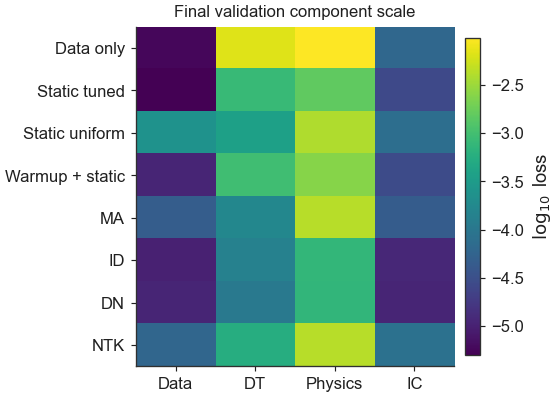

[]

In [8]:
heat = component_agg[[f"val_{c}_loss_mean" for c in COMPONENTS]].to_numpy(dtype=float)
heat_log = np.log10(np.clip(heat, 1e-16, None))

fig, ax = plt.subplots(figsize=(4.8, 3.5))
im = ax.imshow(heat_log, aspect="auto", cmap="viridis", norm=Normalize(vmin=np.nanmin(heat_log), vmax=np.nanmax(heat_log)))
ax.set_xticks(np.arange(len(COMPONENTS)))
ax.set_xticklabels([c.upper() if c in {"dt", "ic"} else c.capitalize() for c in COMPONENTS])
ax.set_yticks(np.arange(len(component_agg)))
ax.set_yticklabels(component_agg["strategy"].map(strategy_label))
ax.set_title("Final validation component scale")
ax.grid(False)
apply_thesis_axis_style(ax)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label(r"$\log_{10}$ loss")
fig.tight_layout()
export_fig(fig, "loss_balancing_final_validation_components")

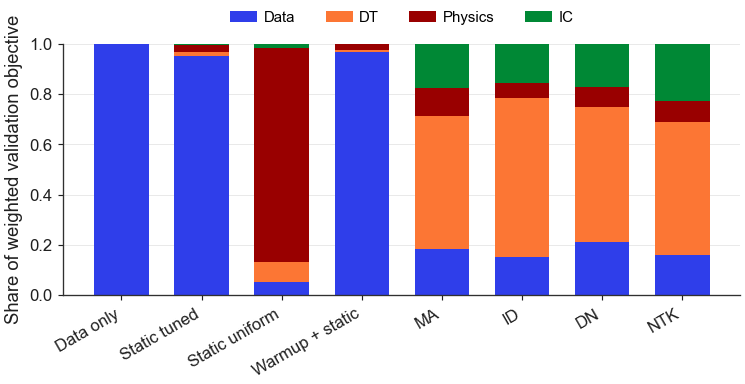

[]

In [9]:
weighted = component_agg[[f"weighted_val_{c}_loss_mean" for c in COMPONENTS]].fillna(0.0).to_numpy(dtype=float)
row_sums = weighted.sum(axis=1, keepdims=True)
composition = np.divide(weighted, row_sums, out=np.zeros_like(weighted), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(6.4, 3.5))
x = np.arange(len(component_agg))
bottom = np.zeros(len(component_agg))
component_colors = [DTU_COLORS["blue"], DTU_COLORS["orange"], DTU_COLORS["corporate_red"], DTU_COLORS["green"]]
for idx, component in enumerate(COMPONENTS):
    ax.bar(x, composition[:, idx], bottom=bottom, color=component_colors[idx], width=0.68, label=component.upper() if component in {"dt", "ic"} else component.capitalize())
    bottom += composition[:, idx]
ax.set_ylim(0, 1)
ax.set_ylabel("Share of weighted validation objective")
ax.set_xticks(x)
ax.set_xticklabels(component_agg["strategy"].map(strategy_label), rotation=30, ha="right")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.18))
ax.grid(True, axis="y")
ax.grid(False, axis="x")
apply_thesis_axis_style(ax)
fig.tight_layout()
export_fig(fig, "loss_balancing_weighted_validation_composition")

## Gradient Telemetry Diagnostics

Gradient telemetry is available for the dedicated s01 telemetry runs. These diagnostics compare component gradient norms across static uniform, static tuned, and DN weighting.

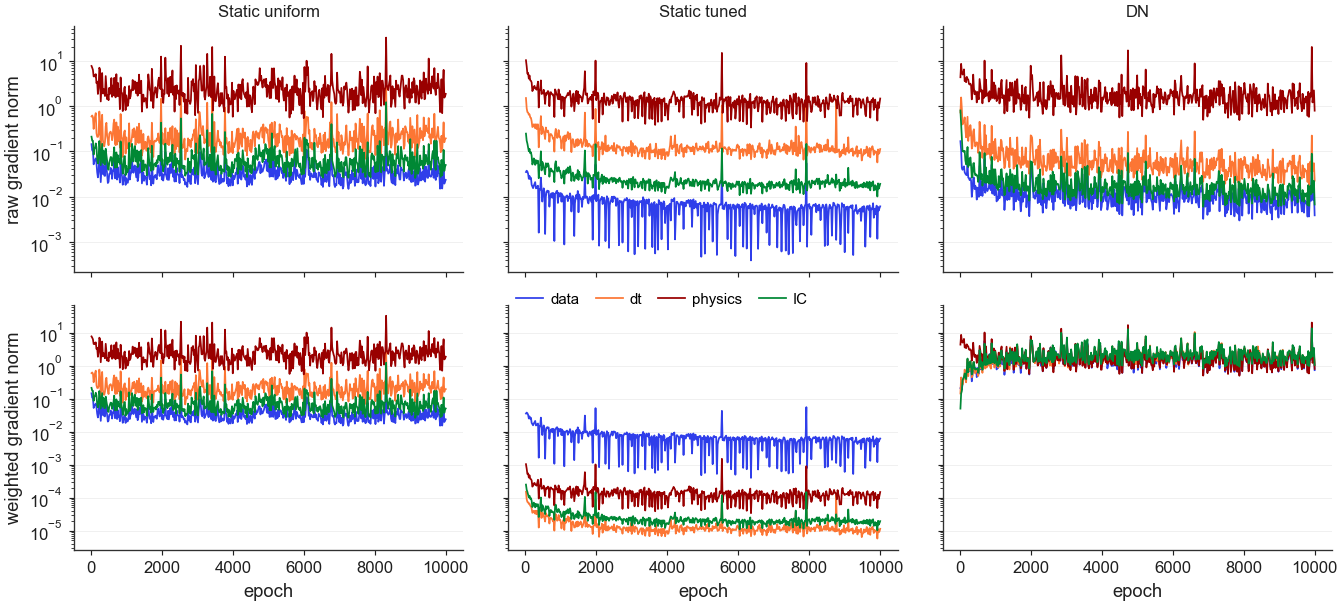

In [10]:
GRADIENT_TELEMETRY_RUNS = {
    "static_uniform": ("20260508_121314", "static_uniform_s01"),
    "static_tuned": ("20260508_121314", "static_tuned_s01"),
    "dn": ("20260510_175445", "dn_s01"),
}
GRADIENT_COMPONENTS = [
    ("data", "train_data_grad_norm", "train_weighted_data_grad_norm", "data"),
    ("dt", "train_dt_grad_norm", "train_weighted_dt_grad_norm", "dt"),
    ("physics", "train_physics_grad_norm", "train_weighted_physics_grad_norm", "physics"),
    ("ic", "train_ic_grad_norm", "train_weighted_ic_grad_norm", "IC"),
]
GRADIENT_COLORS = {
    "data": DTU_COLORS["blue"],
    "dt": DTU_COLORS["orange"],
    "physics": DTU_COLORS["corporate_red"],
    "ic": DTU_COLORS["green"],
}

gradient_frames = []
for strategy, (batch, run_name) in GRADIENT_TELEMETRY_RUNS.items():
    path = epoch_metrics_path(ROOT, batch, run_name)
    frame = read_epoch_metrics(
        path,
        columns=(
            ["global_epoch", "train_total_grad_norm"]
            + [raw_column for _component, raw_column, _weighted_column, _label in GRADIENT_COMPONENTS]
            + [weighted_column for _component, _raw_column, weighted_column, _label in GRADIENT_COMPONENTS]
        ),
    )
    if frame.empty:
        continue
    frame["strategy"] = strategy
    frame["batch"] = batch
    frame["run_name"] = run_name
    gradient_frames.append(frame)

gradient_telemetry = pd.concat(gradient_frames, ignore_index=True, sort=False) if gradient_frames else pd.DataFrame()
if not gradient_telemetry.empty:
    # Scratch export disabled for repository submission; keep derived data in memory.

    fig, axes = plt.subplots(2, 3, figsize=(11.4, 5.35), sharex=True, sharey="row")
    strategy_order = ["static_uniform", "static_tuned", "dn"]
    row_specs = [
        ("raw gradient norm", 1),
        ("weighted gradient norm", 2),
    ]
    legend_handles = []
    for row_idx, (ylabel, column_idx) in enumerate(row_specs):
        for col_idx, strategy in enumerate(strategy_order):
            ax = axes[row_idx, col_idx]
            sub = gradient_telemetry[gradient_telemetry["strategy"] == strategy].copy()
            sub = sub.sort_values("global_epoch")
            if len(sub) > 600:
                sub = sub.iloc[::20].copy()
            for component, raw_column, weighted_column, label in GRADIENT_COMPONENTS:
                column = raw_column if row_idx == 0 else weighted_column
                values = pd.to_numeric(sub[column], errors="coerce")
                line, = ax.plot(
                    sub["global_epoch"],
                    values,
                    color=GRADIENT_COLORS[component],
                    linewidth=1.05,
                    label=label,
                )
                if row_idx == 0 and col_idx == 0:
                    legend_handles.append(line)
            if row_idx == 0:
                ax.set_title(strategy_label(strategy))
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            if row_idx == 1:
                ax.set_xlabel("epoch")
            ax.set_yscale("log")
            ax.grid(True, axis="y", alpha=0.45)
            ax.grid(False, axis="x")
            apply_thesis_axis_style(ax)

    fig.legend(
        handles=legend_handles,
        labels=[label for _component, _raw_column, _weighted_column, label in GRADIENT_COMPONENTS],
        loc="center",
        bbox_to_anchor=(0.5, 0.500),
        ncol=4,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.1,
    )
    fig.subplots_adjust(left=0.070, right=0.990, bottom=0.110, top=0.925, wspace=0.115, hspace=0.135)
    export_fig(fig, "loss_balancing_gradient_evolution_raw_weighted_static_uniform_tuned_dn")
else:
    print("No gradient telemetry rows found for the selected s01 runs.")

## Adaptive Evolution Diagnostics

The evolution plots are averaged over available seeds and shown for the adaptive strategies. They are intended as mechanism diagnostics rather than the main accuracy claim.

In [11]:
EPOCH_COLUMNS = ["global_epoch", "val_total_loss"] + [f"val_{c}_loss" for c in COMPONENTS] + [f"train_weight_{c}" for c in COMPONENTS]
epoch_frames = []
for _, row in primary.iterrows():
    frame = read_epoch_metrics(epoch_metrics_path(ROOT, row.batch, row.run_name), columns=EPOCH_COLUMNS)
    if frame.empty:
        continue
    frame["strategy"] = row.strategy
    frame["seed_label"] = row.seed_label
    epoch_frames.append(frame)

epoch_long = pd.concat(epoch_frames, ignore_index=True, sort=False) if epoch_frames else pd.DataFrame()
epoch_long = epoch_long.dropna(subset=["global_epoch"])
# Scratch export disabled for repository submission; keep derived data in memory.
print(f"Loaded {len(epoch_long):,} epoch rows for evolution diagnostics.")

Loaded 240,024 epoch rows for evolution diagnostics.


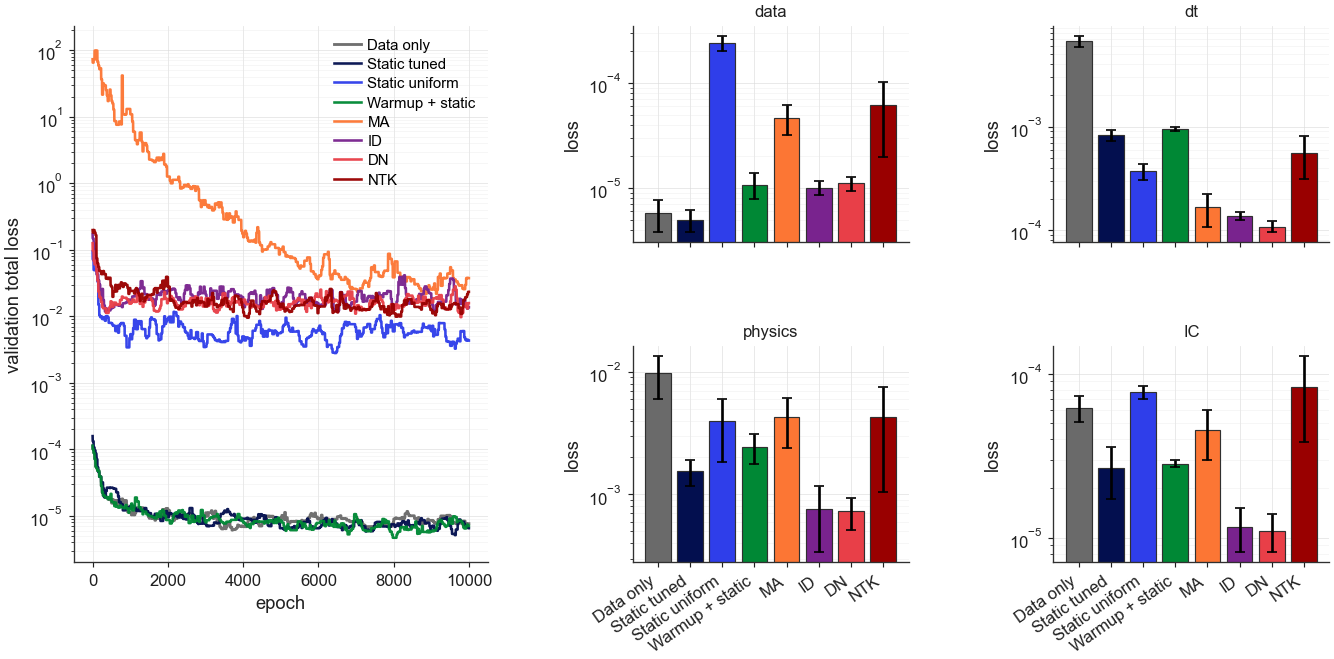

In [12]:
DECOMP_SPECS = [
    ("val_data_loss", "data"),
    ("val_dt_loss", "dt"),
    ("val_physics_loss", "physics"),
    ("val_ic_loss", "IC"),
]
COMPONENT_LABELS = {"data": "data", "dt": "dt", "physics": "physics", "IC": "IC"}

if not epoch_long.empty:
    convergence_strategies = PRIMARY_STRATEGIES
    convergence_metrics = ["val_total_loss"] + [metric for metric, _panel in DECOMP_SPECS]
    convergence = (
        epoch_long[epoch_long["strategy"].isin(convergence_strategies)]
        .groupby(["strategy", "global_epoch"], observed=True)[convergence_metrics]
        .mean()
        .reset_index()
    )
    convergence["strategy"] = pd.Categorical(
        convergence["strategy"].astype(str), categories=convergence_strategies, ordered=True
    )
    convergence = convergence.sort_values(["strategy", "global_epoch"])
    convergence["val_total_loss_smooth"] = (
        convergence.groupby("strategy", observed=True)["val_total_loss"]
        .transform(lambda s: s.rolling(window=200, min_periods=1, center=True).median())
    )
    # Scratch export disabled for repository submission; keep derived data in memory.

    fig, axes = plt.subplot_mosaic(
        [["total", "data", "dt"],
         ["total", "physics", "IC"]],
        figsize=(13.5, 5.8),
        gridspec_kw={"wspace": 0.45, "hspace": 0.48, "width_ratios": [1.5, 1, 1]},
    )

    for strategy, sub in convergence.groupby("strategy", observed=True):
        sub = sub.dropna(subset=["val_total_loss_smooth"])
        if sub.empty:
            continue
        axes["total"].plot(
            sub["global_epoch"],
            sub["val_total_loss_smooth"],
            label=strategy_label(str(strategy)),
            color=STRATEGY_COLORS[str(strategy)],
            linewidth=1.55 if str(strategy) != "data_only" else 1.7,
            alpha=0.96,
        )
    axes["total"].set_yscale("log")
    axes["total"].set_xlabel("epoch")
    axes["total"].set_ylabel("validation total loss")
    axes["total"].legend(ncol=1)
    log_minor_grid(axes["total"], axis="y")
    apply_thesis_axis_style(axes["total"])

    x = np.arange(len(component_agg))
    xlabels = [strategy_label(str(k)) for k in component_agg["strategy"]]
    colors = [STRATEGY_COLORS[str(k)] for k in component_agg["strategy"]]

    for metric, panel in DECOMP_SPECS:
        ax = axes[panel]
        ax.bar(
            x,
            component_agg[f"{metric}_mean"],
            yerr=np.nan_to_num(component_agg[f"{metric}_sem"], nan=0.0),
            capsize=3,
            color=colors,
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
        )
        ax.set_title(COMPONENT_LABELS[panel])
        ax.set_xticks(x)
        ax.set_yscale("log")
        ax.set_ylabel("loss")
        log_minor_grid(ax, axis="y")
        apply_thesis_axis_style(ax)

    for panel in ["data", "dt"]:
        axes[panel].set_xticklabels([])
    for panel in ["physics", "IC"]:
        axes[panel].set_xticklabels(xlabels, rotation=35, ha="right")

    export_fig(fig, "loss_balancing_convergence_decomposition")
else:
    print("No epoch metrics found for convergence diagnostics.")

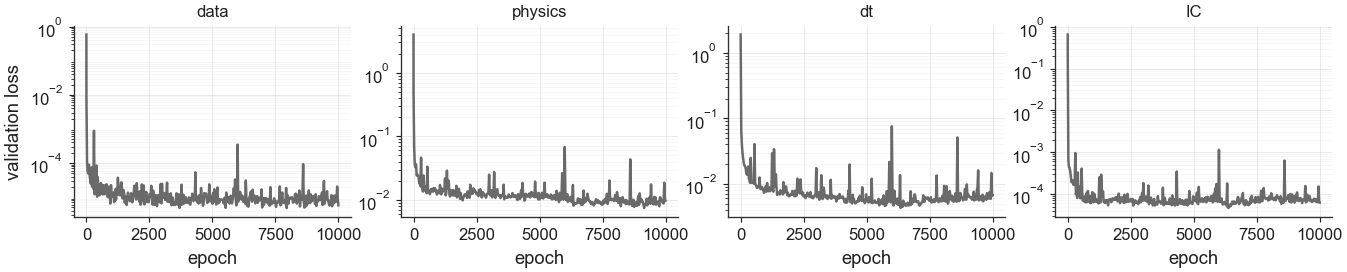

In [13]:
DATA_ONLY_COMPONENT_ORDER = [
    ("val_data_loss", "data"),
    ("val_physics_loss", "physics"),
    ("val_dt_loss", "dt"),
    ("val_ic_loss", "IC"),
]

if not epoch_long.empty:
    data_only_evo = (
        epoch_long[epoch_long["strategy"] == "data_only"]
        .groupby("global_epoch", observed=True)[[metric for metric, _label in DATA_ONLY_COMPONENT_ORDER]]
        .mean()
        .reset_index()
        .sort_values("global_epoch")
    )
    # Scratch export disabled for repository submission; keep derived data in memory.

    fig, axes = plt.subplots(1, 4, figsize=(11.4, 2.65), sharex=True)
    for ax, (metric, label) in zip(axes, DATA_ONLY_COMPONENT_ORDER):
        sub = data_only_evo.dropna(subset=[metric])
        if not sub.empty:
            ax.plot(
                sub["global_epoch"],
                sub[metric],
                color=STRATEGY_COLORS["data_only"],
                linewidth=1.5,
            )
        ax.set_title(label)
        ax.set_xlabel("epoch")
        ax.set_yscale("log")
        log_minor_grid(ax, axis="y")
        apply_thesis_axis_style(ax)
    axes[0].set_ylabel("validation loss")
    fig.subplots_adjust(left=0.070, right=0.990, bottom=0.220, top=0.820, wspace=0.180)
    export_fig(fig, "loss_balancing_data_only_validation_component_evolution")
else:
    print("No epoch metrics found for data-only component evolution.")

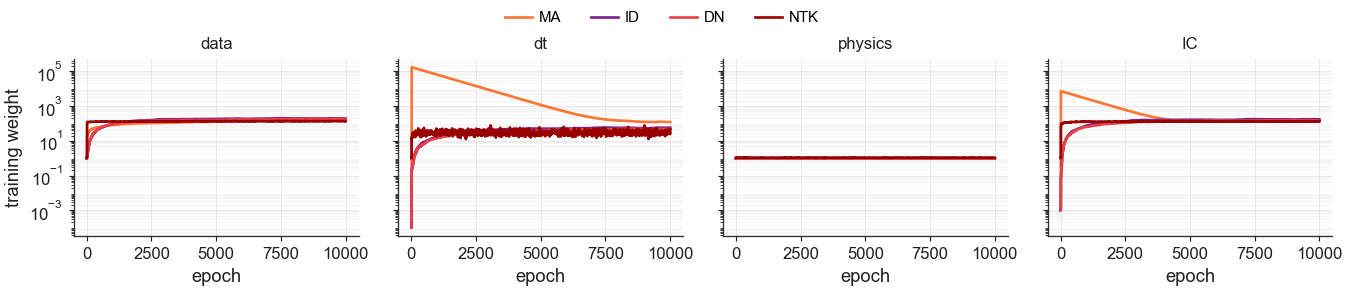

In [14]:
adaptive_epoch = epoch_long[epoch_long["strategy"].isin(ADAPTIVE_STRATEGIES)].copy()
if not adaptive_epoch.empty:
    weight_evo = (
        adaptive_epoch.groupby(["strategy", "global_epoch"], observed=True)[[f"train_weight_{c}" for c in COMPONENTS]]
        .mean()
        .reset_index()
    )
    # Scratch export disabled for repository submission; keep derived data in memory.
    component_labels = {"data": "data", "dt": "dt", "physics": "physics", "ic": "IC"}
    fig, axes = plt.subplots(1, 4, figsize=(11.4, 2.65), sharex=True, sharey=True)
    for ax, component in zip(axes, COMPONENTS):
        metric = f"train_weight_{component}"
        for strategy in ADAPTIVE_STRATEGIES:
            sub = weight_evo[weight_evo["strategy"] == strategy]
            if sub.empty or sub[metric].dropna().empty:
                continue
            ax.plot(sub["global_epoch"], sub[metric], color=STRATEGY_COLORS[strategy], label=strategy_label(strategy))
        ax.set_yscale("log")
        ax.set_title(component_labels[component])
        ax.set_xlabel("epoch")
        log_minor_grid(ax, axis="y")
        apply_thesis_axis_style(ax)
    axes[0].set_ylabel("training weight")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(labels), loc="upper center", bbox_to_anchor=(0.5, 0.965))
    fig.subplots_adjust(left=0.070, right=0.990, bottom=0.220, top=0.775, wspace=0.140)
    export_fig(fig, "loss_balancing_weight_evolution_adaptive")

## Auxiliary ReLoBRaLo Runs

In [15]:
if not auxiliary.empty:
    relobralo_rows = auxiliary[[
        "strategy", "seed_label", "status", "best_id_eval_mse", "best_id_eval_mae",
        "best_ood_eval_mse", "best_ood_eval_mae", "training_seconds", "batch", "run_name"
    ]].copy()
    relobralo_rows["Strategy"] = relobralo_rows["strategy"].map(strategy_label)
    relobralo_rows["Training time [h]"] = relobralo_rows["training_seconds"] / 3600
    relobralo_display = relobralo_rows[[
        "Strategy", "seed_label", "status", "best_id_eval_mse", "best_id_eval_mae",
        "best_ood_eval_mse", "best_ood_eval_mae", "Training time [h]", "batch", "run_name"
    ]]
    # Scratch export disabled for repository submission; keep derived data in memory.
    display(relobralo_display)
else:
    print("No auxiliary ReLoBRaLo runs were retained after duplicate resolution.")

,Strategy,seed_label,status,best_id_eval_mse,best_id_eval_mae,best_ood_eval_mse,best_ood_eval_mae,Training time [h],batch,run_name
24,ReLoBRaLo,s01,completed,NaN,NaN,0.036878,0.087663,10.196403,20260510_175445,relobralo_s01
25,ReLoBRaLo,s02,completed,0.000292,0.011413,0.022240,0.064702,3.764967,20260512_160405,relobralo_s02
26,ReLoBRaLo,s03,completed,0.000433,0.014975,0.028521,0.073382,4.767996,20260514_064843,relobralo_s03
